In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [13]:
import pandas as pd

path = r"C:\Users\sumas\open-data-intelligence-hub\Mentee Contribution\Task 8 - Customer Segmentation with Actionable Business Insights\SumasriG40 AIML\E-commerce Customer Behavior - Sheet1.csv"

df = pd.read_csv(path)

print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [14]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (350, 11)
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 37.4 KB


In [15]:
df.describe(include='all')

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,350.000000,350,350.000000,350,350,350.000000,350.000000,350.000000,350,350.000000,348
unique,NaN,2,NaN,6,3,NaN,NaN,NaN,2,NaN,3
top,NaN,Female,NaN,New York,Gold,NaN,NaN,NaN,True,NaN,Satisfied
freq,NaN,175,NaN,59,117,NaN,NaN,NaN,175,NaN,125
mean,275.500000,NaN,33.597143,NaN,NaN,845.381714,12.600000,4.019143,NaN,26.588571,NaN
std,101.180532,NaN,4.870882,NaN,NaN,362.058695,4.155984,0.580539,NaN,13.440813,NaN
min,101.000000,NaN,26.000000,NaN,NaN,410.800000,7.000000,3.000000,NaN,9.000000,NaN
25%,188.250000,NaN,30.000000,NaN,NaN,502.000000,9.000000,3.500000,NaN,15.000000,NaN
50%,275.500000,NaN,32.500000,NaN,NaN,775.200000,12.000000,4.100000,NaN,23.000000,NaN
75%,362.750000,NaN,37.000000,NaN,NaN,1160.600000,15.000000,4.500000,NaN,38.000000,NaN


In [16]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [17]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [18]:
# Fill numerical columns

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [19]:
df.drop_duplicates(inplace=True)

print(df.shape)

(350, 11)


In [20]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver,Satisfaction Level_Satisfied,Satisfaction Level_Unsatisfied
0,101,29,1120.20,14,4.6,True,25,False,False,False,False,True,False,True,False,True,False
1,102,34,780.50,11,4.1,False,18,True,False,True,False,False,False,False,True,False,False
2,103,43,510.75,9,3.4,True,42,False,False,False,False,False,False,False,False,False,True
3,104,30,1480.30,19,4.7,False,12,True,False,False,False,False,True,True,False,True,False
4,105,27,720.40,13,4.0,True,55,True,False,False,True,False,False,False,True,False,True


In [21]:
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

In [22]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver,Satisfaction Level_Satisfied,Satisfaction Level_Unsatisfied
0,-1.727109,-0.945152,0.760130,0.337346,1.001981,1.0,-0.118359,-1.0,-0.445679,-0.450277,-0.445679,2.220856,-0.445679,1.411189,-0.708623,1.341641,-0.704078
1,-1.717212,0.082826,-0.179459,-0.385538,0.139479,-1.0,-0.639907,1.0,-0.445679,2.220856,-0.445679,-0.450277,-0.445679,-0.708623,1.411189,-0.745356,-0.704078
2,-1.707314,1.933185,-0.925570,-0.867461,-1.068024,1.0,1.148256,-1.0,-0.445679,-0.450277,-0.445679,-0.450277,-0.445679,-0.708623,-0.708623,-0.745356,1.420296
3,-1.697417,-0.739557,1.756144,1.542153,1.174482,-1.0,-1.086947,1.0,-0.445679,-0.450277,-0.445679,-0.450277,2.243765,1.411189,-0.708623,1.341641,-0.704078
4,-1.687519,-1.356343,-0.345692,0.096385,-0.033022,1.0,2.116844,1.0,-0.445679,-0.450277,2.243765,-0.450277,-0.445679,-0.708623,1.411189,-0.745356,1.420296


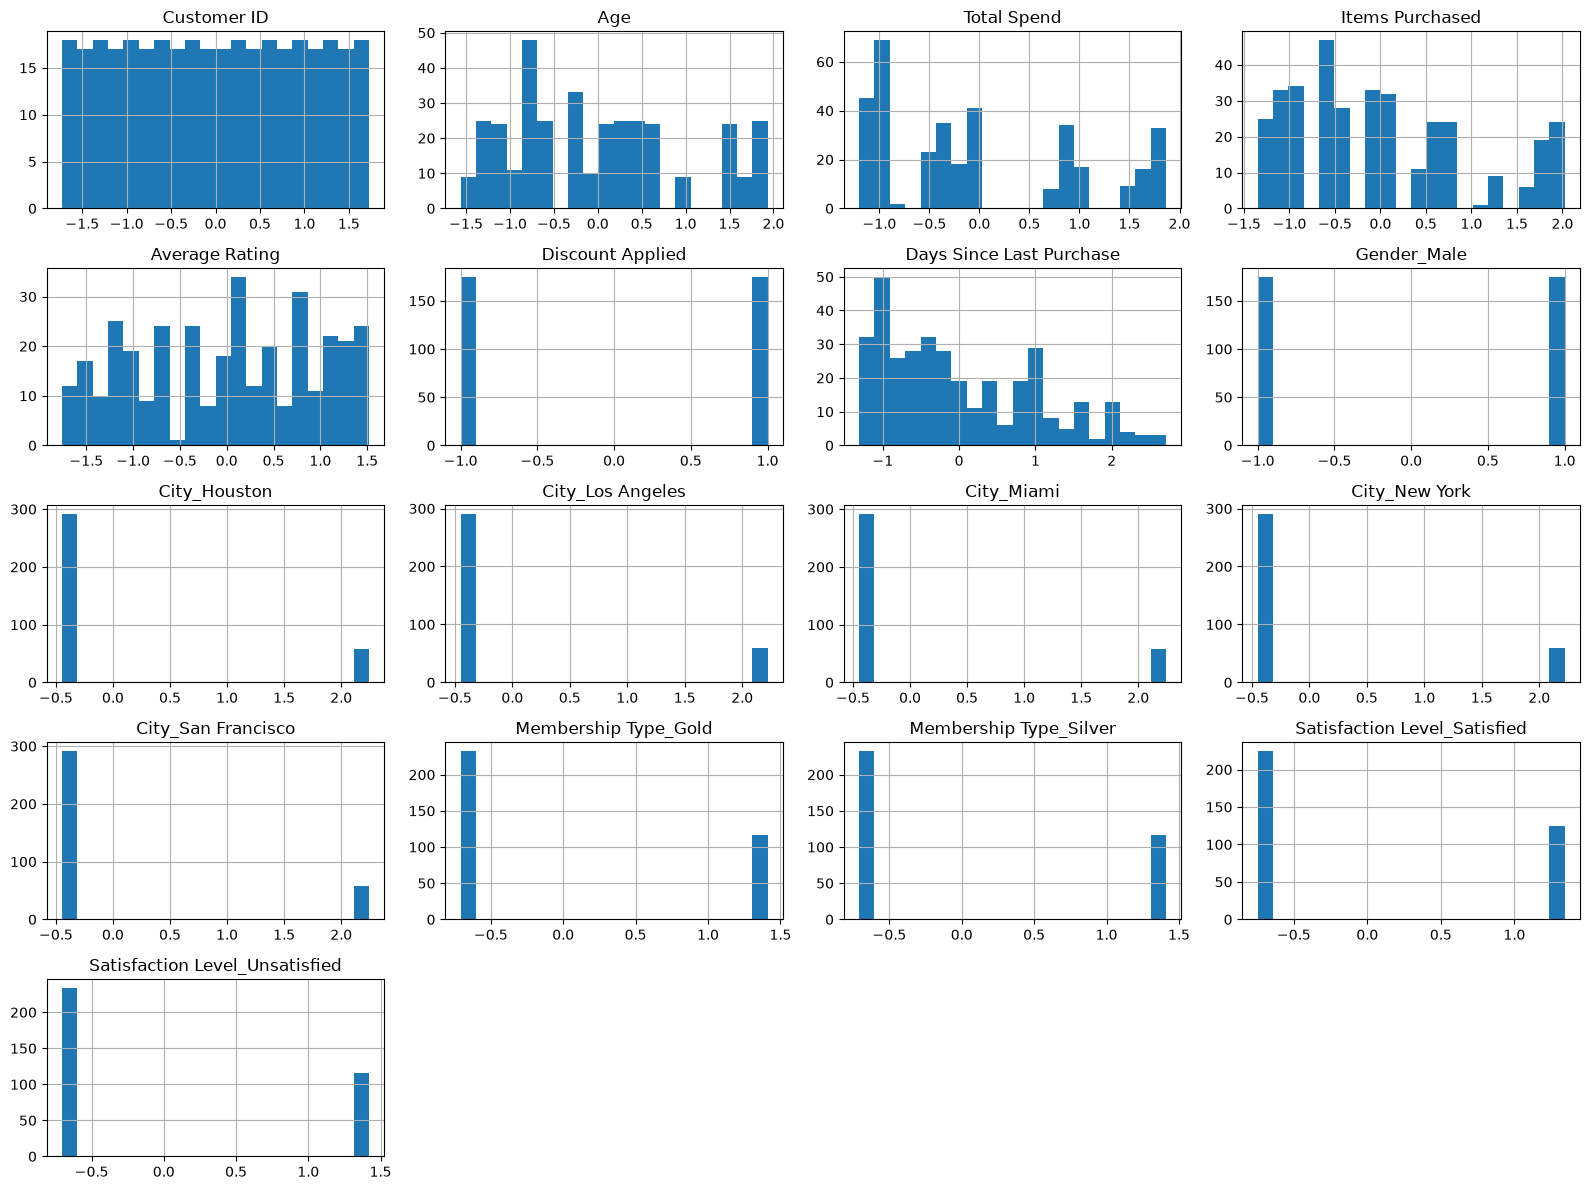

In [23]:
scaled_df.hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

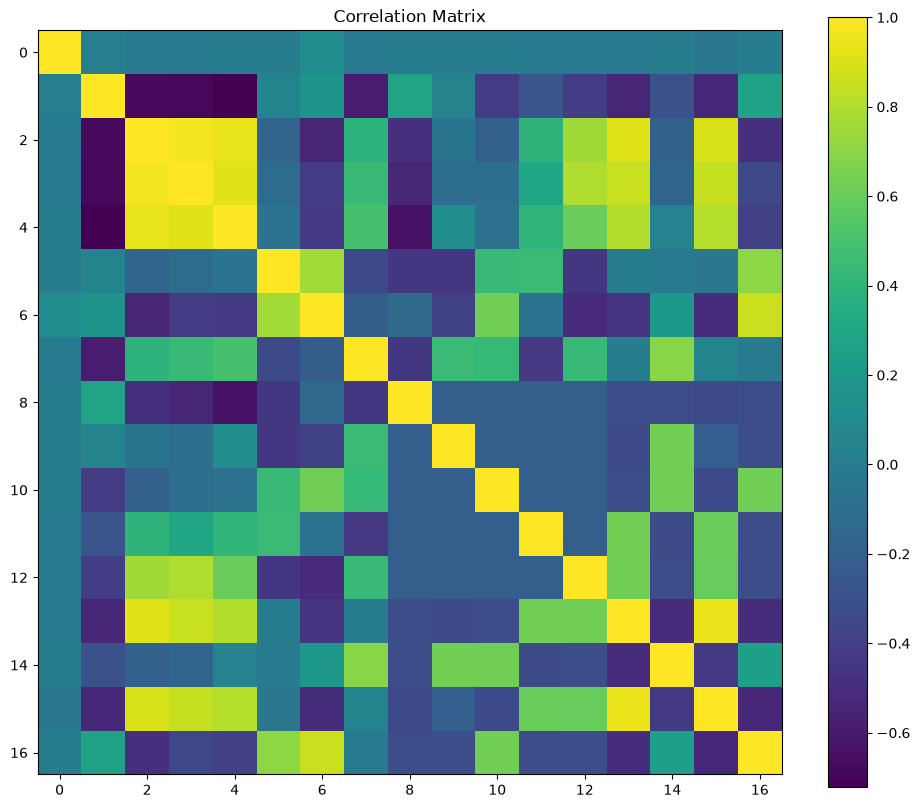

In [24]:
corr = scaled_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

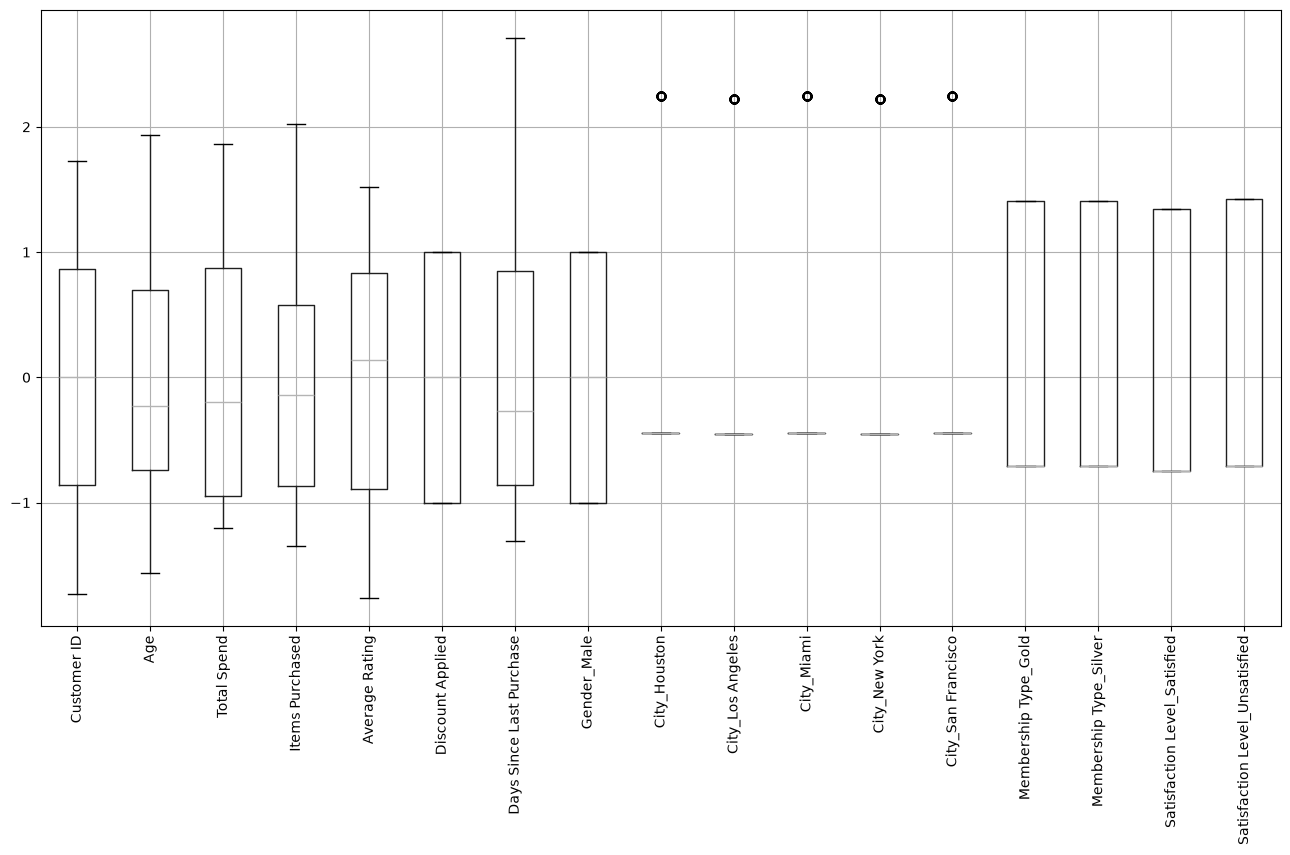

In [25]:
plt.figure(figsize=(16,8))

scaled_df.boxplot(rot=90)

plt.show()

In [26]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_df)

    inertia.append(model.inertia_)

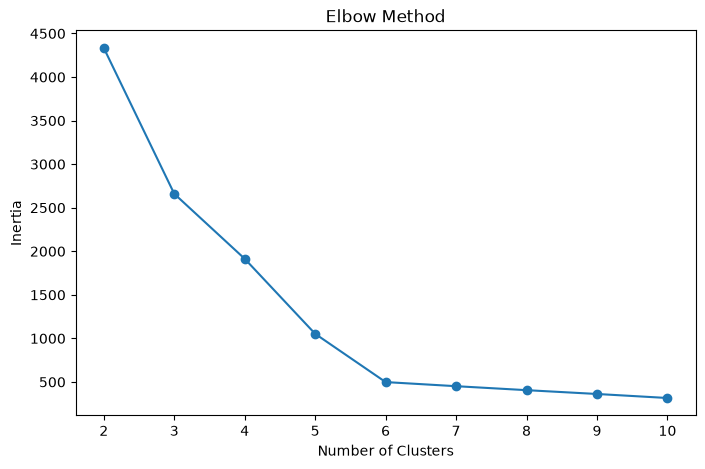

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [28]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    scores.append(score)

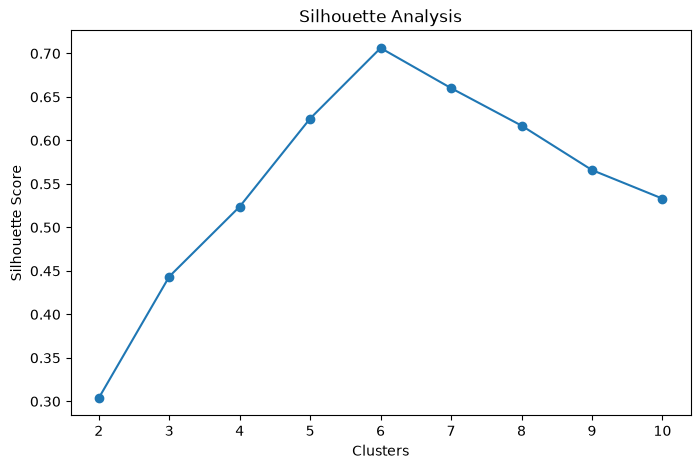

Best Number of Clusters: 6


In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

best_k = np.argmax(scores) + 2

print("Best Number of Clusters:", best_k)

In [30]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_df)

scaled_df["Cluster"] = clusters

In [31]:
scaled_df["Cluster"].value_counts()

Cluster
2    59
4    59
5    58
3    58
1    58
0    58
Name: count, dtype: int64

In [32]:
pca = PCA(n_components=2)

components = pca.fit_transform(scaled_df.drop("Cluster",axis=1))

pca_df = pd.DataFrame()

pca_df["PC1"] = components[:,0]

pca_df["PC2"] = components[:,1]

pca_df["Cluster"] = clusters

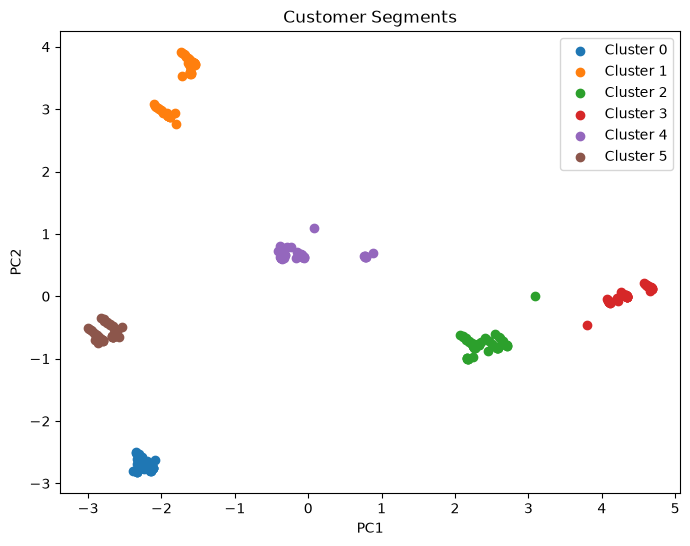

In [33]:
plt.figure(figsize=(8,6))

for c in sorted(pca_df.Cluster.unique()):

    temp = pca_df[pca_df.Cluster==c]

    plt.scatter(
        temp.PC1,
        temp.PC2,
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Customer Segments")

plt.legend()

plt.show()

In [34]:
scaled_df.to_csv(
    "customer_segments.csv",
    index=False
)

print("Customer Segments Saved Successfully")

Customer Segments Saved Successfully


In [35]:
cluster_profile = df.copy()

cluster_profile["Cluster"] = clusters

cluster_summary = cluster_profile.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver,Satisfaction Level_Satisfied,Satisfaction Level_Unsatisfied
Cluster,,,,,,,,,,,,,,,,,
0,276.568966,36.706897,446.894828,7.568966,3.193103,0.0,22.758621,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,275.568966,28.948276,690.389655,11.637931,3.927586,1.0,45.500000,0.982759,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.0
2,274.576271,30.711864,1165.035593,15.271186,4.544068,1.0,24.593220,0.016949,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.000000,0.0
3,274.568966,29.120690,1459.772414,20.000000,4.808621,0.0,11.172414,1.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.000000,0.0
4,275.576271,34.118644,805.491525,11.677966,4.172881,0.0,15.271186,1.000000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.135593,0.0
5,276.155172,42.017241,499.882759,9.413793,3.456897,1.0,40.465517,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0


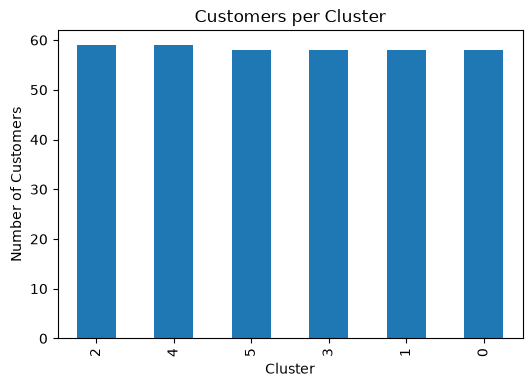

In [36]:
cluster_profile["Cluster"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customers per Cluster"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
import pandas as pd

path = r"C:\Users\sumas\open-data-intelligence-hub\Mentee Contribution\Task 8 - Customer Segmentation with Actionable Business Insights\SumasriG40 AIML\E-commerce Customer Behavior - Sheet1.csv"

df = pd.read_csv(path)

print(df.columns.tolist())

['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']


In [43]:
target = "PurchaseAmount"

In [45]:
print(df.columns.tolist())

['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Target variable
target = "Total Spend"

# Features
X = df.drop(columns=[target, "Customer ID"])

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Target
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.9980868448494546
RMSE: 16.08385718508299


In [50]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Regression")

print("R2 Score:", r2_score(y_test, ridge_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge Regression
R2 Score: 0.9959515480870996
RMSE: 23.396969293899335


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [56]:
print(df["Satisfaction Level"].unique())

<ArrowStringArray>
['Satisfied', 'Neutral', 'Unsatisfied', nan]
Length: 4, dtype: str


In [57]:
from sklearn.preprocessing import LabelEncoder

# Convert Satisfaction Level to numbers
le = LabelEncoder()
df["Satisfied"] = le.fit_transform(df["Satisfaction Level"])

print(df[["Satisfaction Level", "Satisfied"]].head())

  Satisfaction Level  Satisfied
0          Satisfied          1
1            Neutral          0
2        Unsatisfied          2
3          Satisfied          1
4        Unsatisfied          2


In [58]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Satisfied", "Satisfaction Level", "Customer ID"])

X = pd.get_dummies(X, drop_first=True)

y = df["Satisfied"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Remove rows with missing Satisfaction Level
df = df.dropna(subset=["Satisfaction Level"])

# Encode target column
target_encoder = LabelEncoder()
df["Satisfied"] = target_encoder.fit_transform(df["Satisfaction Level"])

# Features
X = df.drop(columns=["Customer ID", "Satisfaction Level", "Satisfied"])

# Encode categorical feature columns
X = pd.get_dummies(X, drop_first=True)

# Target
y = df["Satisfied"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression
model = LogisticRegression(max_iter=1000)

# Hyperparameter Tuning
params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(
    model,
    params,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, prediction))
print(classification_report(y_test, prediction))

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



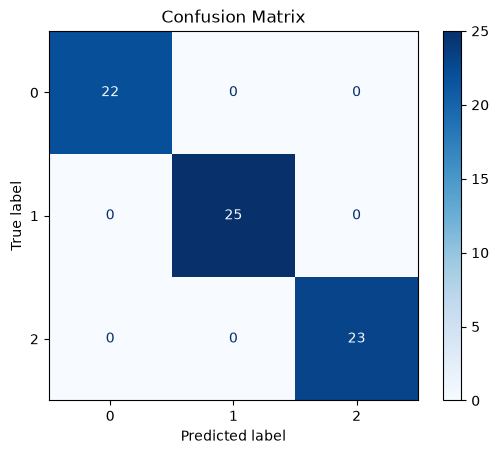

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [61]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print(importance.head(10))

                   Feature  Coefficient
0                      Age     0.349478
3           Average Rating     0.117522
7             City_Houston     0.092625
10           City_New York     0.057128
12    Membership Type_Gold     0.056252
8         City_Los Angeles     0.044491
11      City_San Francisco    -0.000876
1              Total Spend    -0.032649
13  Membership Type_Silver    -0.097684
6              Gender_Male    -0.098581


In [62]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Predicted"] = prediction

results.to_csv("customer_predictions.csv", index=False)

print("Predictions saved successfully.")

Predictions saved successfully.


In [66]:
print(df.columns)

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level', 'Satisfied'],
      dtype='str')


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numerical columns
X_cluster = df[[
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Train K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster Summary
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Total Spend": "mean",
    "Items Purchased": "mean",
    "Average Rating": "mean",
    "Days Since Last Purchase": "mean"
})

print(cluster_summary)

               Age  Total Spend  Items Purchased  Average Rating  \
Cluster                                                            
0        39.403509   474.223684         8.517544        3.326316   
1        29.397590  1378.513253        18.807229        4.745783   
2        31.476821   838.105298        12.344371        4.152980   

         Days Since Last Purchase  
Cluster                            
0                       31.780702  
1                       14.253012  
2                       29.509934  


In [69]:
print(df["Cluster"].value_counts())

Cluster
2    151
0    114
1     83
Name: count, dtype: int64


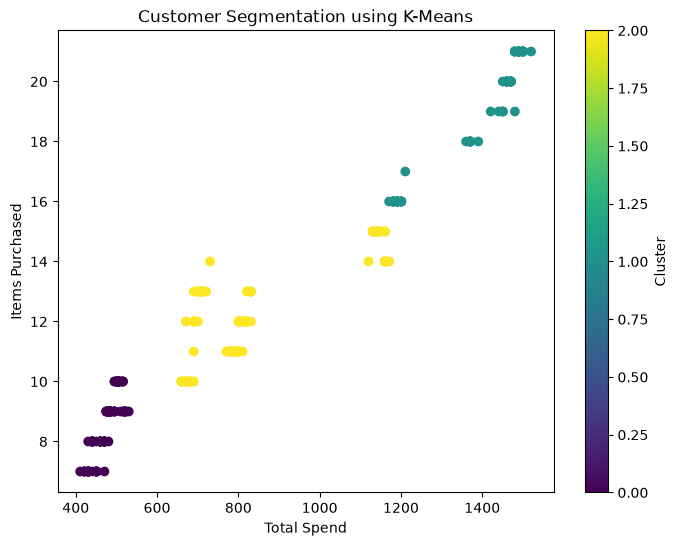

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Total Spend"],
    df["Items Purchased"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Total Spend")
plt.ylabel("Items Purchased")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.show()

Cluster
0     474.223684
1    1378.513253
2     838.105298
Name: Total Spend, dtype: float64


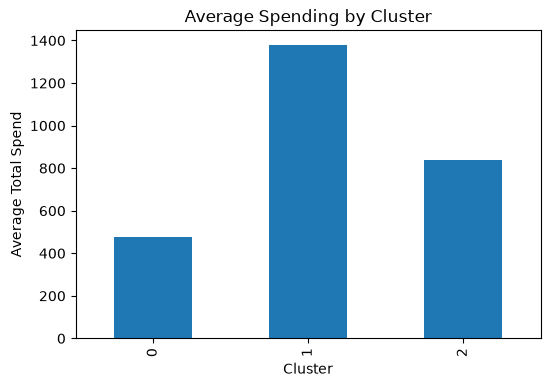

In [71]:
avg_spend = df.groupby("Cluster")["Total Spend"].mean()

print(avg_spend)

avg_spend.plot(kind="bar", figsize=(6,4))

plt.title("Average Spending by Cluster")

plt.ylabel("Average Total Spend")

plt.show()

Membership Type  Bronze  Gold  Silver
Cluster                              
0                   114     0       0
1                     0    83       0
2                     0    34     117


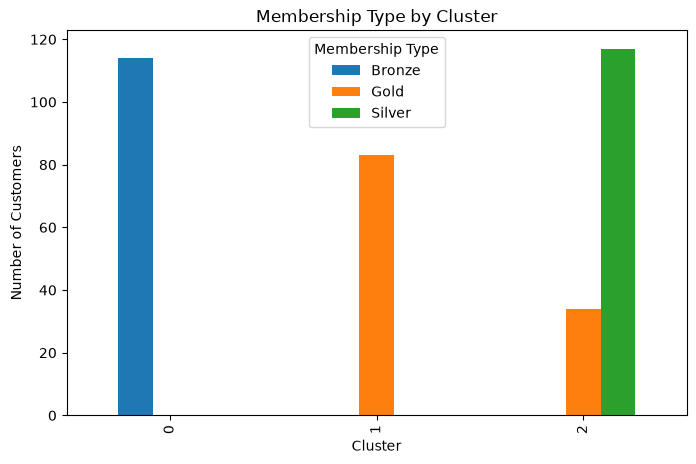

In [72]:
membership = pd.crosstab(df["Cluster"], df["Membership Type"])

print(membership)

membership.plot(kind="bar", figsize=(8,5))

plt.title("Membership Type by Cluster")

plt.ylabel("Number of Customers")

plt.show()

Satisfaction Level  Neutral  Satisfied  Unsatisfied
Cluster                                            
0                        56          0           58
1                         0         83            0
2                        51         42           58


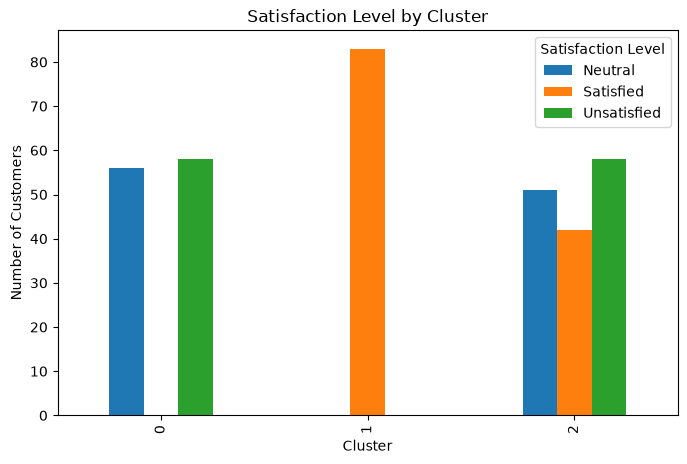

In [73]:
satisfaction = pd.crosstab(df["Cluster"], df["Satisfaction Level"])

print(satisfaction)

satisfaction.plot(kind="bar", figsize=(8,5))

plt.title("Satisfaction Level by Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [74]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [75]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("1. Customers are grouped into three clusters using K-Means.")
print("2. Customers with higher Total Spend are valuable customers.")
print("3. Premium members generally spend more than standard members.")
print("4. Customers with lower spending can be targeted using discounts.")
print("5. Personalized marketing campaigns can improve customer satisfaction.")
print("6. Businesses should focus on retaining high-value customers.")

BUSINESS INSIGHTS
1. Customers are grouped into three clusters using K-Means.
2. Customers with higher Total Spend are valuable customers.
3. Premium members generally spend more than standard members.
4. Customers with lower spending can be targeted using discounts.
5. Personalized marketing campaigns can improve customer satisfaction.
6. Businesses should focus on retaining high-value customers.


In [76]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("✓ Data Cleaning Completed")
print("✓ Exploratory Data Analysis Completed")
print("✓ Customer Segmentation using K-Means Completed")
print("✓ Linear Regression Completed")
print("✓ Ridge Regression Completed")
print("✓ Logistic Regression Completed")
print("✓ Hyperparameter Tuning Completed")
print("✓ Business Insights Generated")
print("✓ Final Dataset Exported Successfully")

PROJECT COMPLETED SUCCESSFULLY
✓ Data Cleaning Completed
✓ Exploratory Data Analysis Completed
✓ Customer Segmentation using K-Means Completed
✓ Linear Regression Completed
✓ Ridge Regression Completed
✓ Logistic Regression Completed
✓ Hyperparameter Tuning Completed
✓ Business Insights Generated
✓ Final Dataset Exported Successfully
